# Installations and Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 76.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
from transformers import BertTokenizer, BertModel
from sklearn.metrics.pairwise import cosine_similarity

In [5]:
import gensim.downloader as api

glove_word_vectors = api.load('glove-wiki-gigaword-100')
word2vec_word_vectors = api.load('word2vec-google-news-300')

[==================================================] 100.0% 128.1/128.1MB downloaded
[==================================================] 100.0% 1662.8/1662.8MB downloaded


# Glove word Embeddings

In [8]:
glove_word_vectors['man'].shape

(100,)

In [9]:
glove_word_vectors['man'][:20]

array([ 0.37293  ,  0.38503  ,  0.71086  , -0.65911  , -0.0010128,
        0.92715  ,  0.27615  , -0.056203 , -0.24294  ,  0.24632  ,
       -0.18449  ,  0.31398  ,  0.48983  ,  0.09256  ,  0.32958  ,
        0.15056  ,  0.57317  , -0.18529  , -0.52277  ,  0.46191  ],
      dtype=float32)

In [10]:
# Words to visualize
words = ["king", "princess", "monarch", "throne", "crown",
         "mountain", "ocean", "tv", "man", "cloud", "queen"]

# Get word vectors
vectors = np.array([glove_word_vectors[word] for word in words])

# Reduce dimensions using PCA
pca = PCA(n_components=2)
vectors_pca = pca.fit_transform(vectors)

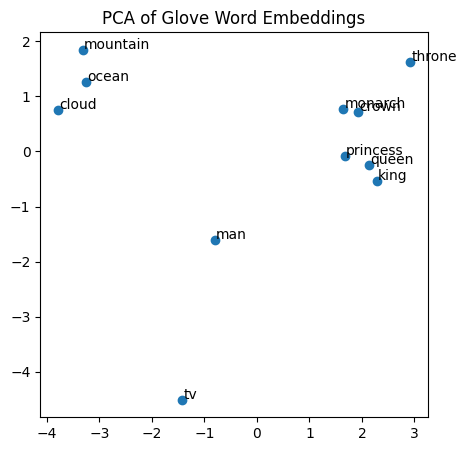

In [11]:
# Plotting
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
axes.scatter(vectors_pca[:, 0], vectors_pca[:, 1])
for i, word in enumerate(words):
    axes.annotate(word, (vectors_pca[i, 0]+.02, vectors_pca[i, 1]+.02))
axes.set_title('PCA of Glove Word Embeddings')
plt.show()

### using our famous example

In [ ]:
result = glove_word_vectors.most_similar(positive=['king', 'woman'],
                                   negative=['man'], topn=1)

# Output the result
print(f"""
    The word closest to 'king' - 'man' + 'woman' is: '{result[0][0]}'
    with a similarity score of {result[0][1]}""")

In [14]:
result = glove_word_vectors.most_similar(positive=['paris', 'spain'],
                                   negative=['france'], topn=1)

# Output the result
print(f"""
    The word closest to 'paris' - 'france' + 'spain' is: '{result[0][0]}'
    with a similarity score of {result[0][1]}""")


    The word closest to 'king' - 'man' + 'woman' is: 'madrid' 
    with a similarity score of 0.8061118125915527


# Word2vec word embeddings

In [15]:
word2vec_word_vectors['man'].shape

(300,)

In [16]:
word2vec_word_vectors['man'][:20]

array([ 0.32617188,  0.13085938,  0.03466797, -0.08300781,  0.08984375,
       -0.04125977, -0.19824219,  0.00689697,  0.14355469,  0.0019455 ,
        0.02880859, -0.25      , -0.08398438, -0.15136719, -0.10205078,
        0.04077148, -0.09765625,  0.05932617,  0.02978516, -0.10058594],
      dtype=float32)

In [17]:
# Words to visualize
words = ["king", "princess", "monarch", "throne", "crown",
         "mountain", "ocean", "tv", "man", "cloud", "queen"]

# Get word vectors
vectors = np.array([word2vec_word_vectors[word] for word in words])

# Reduce dimensions using PCA
pca = PCA(n_components=2)
vectors_pca = pca.fit_transform(vectors)

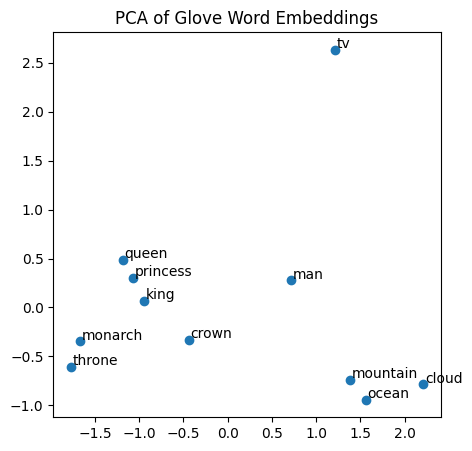

In [18]:
# Plotting
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
axes.scatter(vectors_pca[:, 0], vectors_pca[:, 1])
for i, word in enumerate(words):
    axes.annotate(word, (vectors_pca[i, 0]+.02, vectors_pca[i, 1]+.02))
axes.set_title('PCA of Glove Word Embeddings')
plt.show()

In [20]:
result = word2vec_word_vectors.most_similar(positive=['paris', 'spain'],
                                   negative=['france'], topn=1)

# Output the result
print(f"""
    The word closest to 'paris' - 'france' + 'spain' is: '{result[0][0]}'
    with a similarity score of {result[0][1]}""")


    The word closest to 'paris' - 'france' + 'spain' is: 'madrid' 
    with a similarity score of 0.5295541882514954


# ***But how do we solve the "context" problem ? , we transition to contextualized token embeddings***

In [22]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

# Function to get BERT embeddings
def get_bert_embeddings(sentence, word):
    inputs = tokenizer(sentence, return_tensors='pt')
    outputs = model(**inputs)
    last_hidden_states = outputs.last_hidden_state
    word_tokens = tokenizer.tokenize(sentence)
    word_index = word_tokens.index(word)
    word_embedding = last_hidden_states[0, word_index + 1, :]  # +1 to account for [CLS] token
    return word_embedding

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [23]:
sentence1:str = "The crane waded through the marsh looking for fish." # Nature
sentence2:str = "The operator used the crane to lift the steel beam." # construction

word:str = "crane"

bert_embedding1 = get_bert_embeddings(sentence1, word).detach().numpy()
bert_embedding2 = get_bert_embeddings(sentence2, word).detach().numpy()
glove_word_embedding = glove_word_vectors[word]

In [24]:
print("BERT Embedding for 'crane' in sentence 1:", bert_embedding1[:5])
print("BERT Embedding for 'crane' in sentence 2:", bert_embedding2[:5])
print("GloVe Embedding for 'crane':", glove_word_embedding[:5])

bert_similarity = cosine_similarity([bert_embedding1], [bert_embedding2])[0][0]
word_embedding_similarity = cosine_similarity([glove_word_embedding], [glove_word_embedding])[0][0]

print()
print(f"Cosine Similarity between BERT embeddings in different contexts: {bert_similarity}")
print(f"Cosine Similarity between GloVe embeddings: {word_embedding_similarity}")


BERT Embedding for 'bat' in sentence 1: [ 1.2261658  -0.09001395 -0.8381399   0.27103543  0.31455553]
BERT Embedding for 'bat' in sentence 2: [1.2935671  0.10651106 0.38972792 0.01686277 0.7347425 ]
GloVe Embedding for 'bat': [ 0.012106  0.13492  -0.67688  -0.58392  -0.27246 ]

Cosine Similarity between BERT embeddings in different contexts: 0.5825037956237793
Cosine Similarity between GloVe embeddings: 1.0


# ***the power of ollama comes handy here too***

In [1]:
import subprocess
import time

!sudo apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh

process = subprocess.Popen(["ollama", "serve"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

print("Starting server...")
time.sleep(5)
print("Ollama installed and running successfully!")


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 37 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 1s (848 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 121852 files and directories currently i

In [2]:
!ollama pull nomic-embed-text

In [3]:
!ollama list

NAME                       ID              SIZE      MODIFIED               
nomic-embed-text:latest    0a109f422b47    274 MB    Less than a second ago    


In [4]:
!pip install Ollama

In [38]:
import ollama

# 1. Define your text with the required Nomic prefix
# Use "search_document:" for data you are storing
# Use "search_query:" for a question you are asking
text = "search_document: The operator used the crane to lift the steel beam."
# 2. Get the embedding
response = ollama.embed(
    model='nomic-embed-text',
    input=text
)
# 3. Access the vector
embedding = response['embeddings'][0]

print(f"Vector Length: {len(embedding)}")
print(f"First 5 values: {embedding[:5]}")

Vector Length: 768
First 5 values: [0.00900607, 0.0350603, -0.16377904, 0.0077380696, 0.054261662]


In [37]:
import ollama
import numpy as np

def get_embedding(text):
    # Nomic requires a prefix: 'search_document:' for the data
    response = ollama.embed(model='nomic-embed-text', input=f"search_document: {text}")
    return np.array(response['embeddings'][0])

# 1. Nature context
s1 = "The crane waded through the marsh looking for fish."
# 2. Construction context
s2 = "The operator used the crane to lift the steel beam."
# 3. Another Nature context (for comparison)
s3 = "A large heron flew over the swampy wetlands."

# Get vectors
v1 = get_embedding(s1)
v2 = get_embedding(s2)
v3 = get_embedding(s3)

# Compare
print(f"Similarity (Bird vs. Machine): {cosine_similarity(v1, v2)}")
print(f"Similarity (Bird vs. Heron):   {cosine_similarity(v1, v3)}")

Similarity (Bird vs. Machine): 0.6990891132235111
Similarity (Bird vs. Heron):   0.7440525502354413


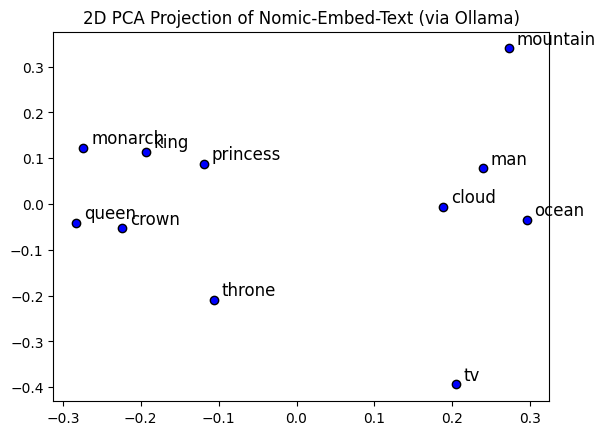

In [10]:
import ollama
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Words to visualize
words = ["king", "princess", "monarch", "throne", "crown",
         "mountain", "ocean", "tv", "man", "cloud", "queen"]

# 2. Get embeddings from Ollama using Nomic
vectors = []
for word in words:
    # We treat each word as a document for embedding purposes
    response = ollama.embed(model='nomic-embed-text', input=f"search_document: {word}")
    vectors.append(response['embeddings'][0])

vectors = np.array(vectors)

# 3. Reduce dimensions from 768 to 2 using PCA
pca = PCA(n_components=2)
vectors_pca = pca.fit_transform(vectors)

# 4. Plotting
# plt.figure(figsize=(10, 8))
plt.scatter(vectors_pca[:, 0], vectors_pca[:, 1], c='blue', edgecolors='k')

for i, word in enumerate(words):
    plt.annotate(word, (vectors_pca[i, 0] + 0.01, vectors_pca[i, 1] + 0.01), fontsize=12)

plt.title('2D PCA Projection of Nomic-Embed-Text (via Ollama)')
# plt.grid(False)
plt.show()